In [1]:
from sklearn.preprocessing import LabelEncoder, OneHotEncoder, StandardScaler, MinMaxScaler
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix, classification_report
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV, LeaveOneOut, cross_val_score, ShuffleSplit, StratifiedKFold, StratifiedShuffleSplit



# Подготовка данных

In [2]:
df = pd.read_csv("datasets/Sleep_health_and_lifestyle_dataset.csv")

In [3]:
df.describe

<bound method NDFrame.describe of      Person ID  Gender  Age            Occupation  Sleep Duration  \
0            1    Male   27     Software Engineer             6.1   
1            2    Male   28                Doctor             6.2   
2            3    Male   28                Doctor             6.2   
3            4    Male   28  Sales Representative             5.9   
4            5    Male   28  Sales Representative             5.9   
..         ...     ...  ...                   ...             ...   
369        370  Female   59                 Nurse             8.1   
370        371  Female   59                 Nurse             8.0   
371        372  Female   59                 Nurse             8.1   
372        373  Female   59                 Nurse             8.1   
373        374  Female   59                 Nurse             8.1   

     Quality of Sleep  Physical Activity Level  Stress Level BMI Category  \
0                   6                       42             6

In [4]:
df.columns = df.columns.str.replace(" ", "_").str.lower()

In [5]:
df.shape

(374, 13)

In [6]:
df.dtypes

person_id                    int64
gender                      object
age                          int64
occupation                  object
sleep_duration             float64
quality_of_sleep             int64
physical_activity_level      int64
stress_level                 int64
bmi_category                object
blood_pressure              object
heart_rate                   int64
daily_steps                  int64
sleep_disorder              object
dtype: object

In [7]:
df.columns

Index(['person_id', 'gender', 'age', 'occupation', 'sleep_duration',
       'quality_of_sleep', 'physical_activity_level', 'stress_level',
       'bmi_category', 'blood_pressure', 'heart_rate', 'daily_steps',
       'sleep_disorder'],
      dtype='object')

In [8]:
df.bmi_category = df.bmi_category.replace({'Normal Weight' : 'Normal'})

In [9]:
for column in df.columns:
    unique_values = df[column].unique()
    if len(unique_values) < 20:
        print(f"{column}: {unique_values}")

gender: ['Male' 'Female']
occupation: ['Software Engineer' 'Doctor' 'Sales Representative' 'Teacher' 'Nurse'
 'Engineer' 'Accountant' 'Scientist' 'Lawyer' 'Salesperson' 'Manager']
quality_of_sleep: [6 4 7 5 8 9]
physical_activity_level: [42 60 30 40 75 35 45 50 32 70 80 55 90 47 65 85]
stress_level: [6 8 7 4 3 5]
bmi_category: ['Overweight' 'Normal' 'Obese']
heart_rate: [77 75 85 82 70 80 78 69 72 68 76 81 65 84 74 67 73 83 86]
sleep_disorder: [nan 'Sleep Apnea' 'Insomnia']


In [10]:
df.sleep_disorder = df.sleep_disorder.fillna("None")


In [11]:
nan_counts = df.isna().sum()
print(nan_counts)

person_id                  0
gender                     0
age                        0
occupation                 0
sleep_duration             0
quality_of_sleep           0
physical_activity_level    0
stress_level               0
bmi_category               0
blood_pressure             0
heart_rate                 0
daily_steps                0
sleep_disorder             0
dtype: int64


# Кодирование категориальных переменных

In [12]:
le = LabelEncoder()

bmi_map = {'Normal': 0, 'Overweight': 1, 'Obese': 2}

df.bmi_category = df.bmi_category.map(bmi_map)

df.gender = le.fit_transform(df.gender)

df.sleep_disorder = le.fit_transform(df.sleep_disorder)

In [13]:
ohe = OneHotEncoder(sparse_output=False, drop='first')

# Кодируем профессии
occupation_encoded = ohe.fit_transform(df[['occupation']])
occupation_categories = ohe.get_feature_names_out(['occupation'])
occupation_columns = list(occupation_categories)

df = pd.concat([
    df,
    pd.DataFrame(occupation_encoded, columns=occupation_columns),
], axis=1)

df = df.drop(['occupation'], axis=1)


# Обработка данных кровяного давления

In [14]:
print(df.blood_pressure)

0      126/83
1      125/80
2      125/80
3      140/90
4      140/90
        ...  
369    140/95
370    140/95
371    140/95
372    140/95
373    140/95
Name: blood_pressure, Length: 374, dtype: object


In [15]:
df[['systolic', 'diastolic']] = df.blood_pressure.str.split('/', expand=True).astype(int)

df = df.drop('blood_pressure', axis=1)

print(df[['systolic', 'diastolic']].head())


   systolic  diastolic
0       126         83
1       125         80
2       125         80
3       140         90
4       140         90


# Масштабирование числовых признаков

In [16]:
numeric_columns = df.select_dtypes(include=['int64', 'float64']).columns
numeric_columns = numeric_columns.drop(occupation_columns + ['sleep_disorder', 'person_id', 'gender', 'bmi_category'])
print("Числовые колонки:")
print(numeric_columns.tolist())


Числовые колонки:
['age', 'sleep_duration', 'quality_of_sleep', 'physical_activity_level', 'stress_level', 'heart_rate', 'daily_steps', 'systolic', 'diastolic']


In [17]:
df_minmax = df.copy()
df_standard = df.copy()

standard_scaler = StandardScaler()
minmax_scaler = MinMaxScaler()

df_standard[numeric_columns] = standard_scaler.fit_transform(df[numeric_columns])

df_minmax[numeric_columns] = minmax_scaler.fit_transform(df[numeric_columns])

print("Стандартизированный скейлер:")
print(df_standard.drop(occupation_columns, axis=1).head(2))
print("Минимаксный скейлер:")
print(df_minmax.drop(occupation_columns, axis=1).head(2))



Стандартизированный скейлер:
   person_id  gender       age  sleep_duration  quality_of_sleep  \
0          1       1 -1.753096       -1.298887          -1.09828   
1          2       1 -1.637643       -1.173036          -1.09828   

   physical_activity_level  stress_level  bmi_category  heart_rate  \
0                -0.825418      0.347021             1    1.654719   
1                 0.039844      1.475592             0    1.170474   

   daily_steps  sleep_disorder  systolic  diastolic  
0    -1.619584               1 -0.330002  -0.268102  
1     1.970077               1 -0.459239  -0.755640  
Минимаксный скейлер:
   person_id  gender      age  sleep_duration  quality_of_sleep  \
0          1       1  0.00000        0.111111               0.4   
1          2       1  0.03125        0.148148               0.4   

   physical_activity_level  stress_level  bmi_category  heart_rate  \
0                      0.2           0.6             1    0.571429   
1                      0.5    

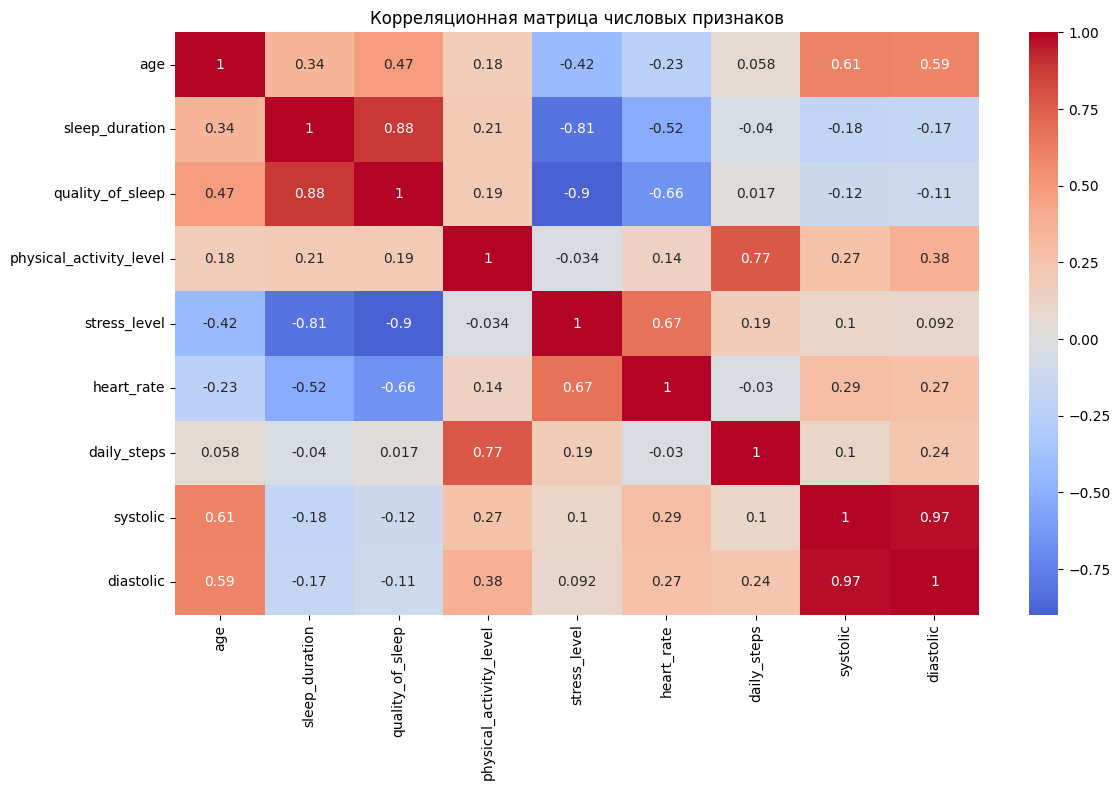

In [18]:
plt.figure(figsize=(12, 8))
sns.heatmap(df_standard[numeric_columns].corr(), 
            annot=True, 
            cmap='coolwarm', 
            center=0)
plt.title('Корреляционная матрица числовых признаков')
plt.tight_layout()

In [19]:
# Сохраняем обработанный датасет со стандартизированным масштабированием
df_standard.to_csv('datasets/Sleep_health_and_lifestyle_dataset_processed.csv', index=False)


# Разделения выборки на обучающую и тестовую

In [20]:
X = df_standard.drop(['sleep_disorder', 'person_id'], axis=1)
y = df_standard['sleep_disorder']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)


In [21]:
print("Обучающая выборка:")
print(y_train.value_counts())
print("Тестовая выборка:")
print(y_test.value_counts())

Обучающая выборка:
sleep_disorder
1    175
2     62
0     62
Name: count, dtype: int64
Тестовая выборка:
sleep_disorder
1    44
2    16
0    15
Name: count, dtype: int64


# Обучения модели KNN для произвольно заданного гиперпараметра K

In [22]:
KNN = KNeighborsClassifier(n_neighbors=10)
KNN.fit(X_train, y_train)

# Предсказание на тестовой выборке
y_pred_test = KNN.predict(X_test)

In [23]:
print(y_pred_test)

[0 0 2 2 0 0 1 0 2 1 0 1 1 2 0 1 2 1 1 1 1 1 1 2 0 1 1 2 2 2 1 1 1 1 2 1 1
 2 2 1 1 1 1 0 1 1 0 2 1 2 2 1 0 0 1 1 0 1 1 2 2 1 1 0 1 1 1 2 1 2 1 1 1 2
 1]


# Оценка качества модели с помощью подходящих для задачи метрик

In [24]:
# Предсказания для обучающей выборки
y_pred_train = KNN.predict(X_train)

# Оценка точности на обучающей и тестовой выборках
accuracy_train = accuracy_score(y_train, y_pred_train)
accuracy_test = accuracy_score(y_test, y_pred_test)

print(f"Accuracy на обучающей выборке: {accuracy_train:.2f}")
print(f"Accuracy на тестовой выборке: {accuracy_test:.2f}")


Accuracy на обучающей выборке: 0.89
Accuracy на тестовой выборке: 0.92


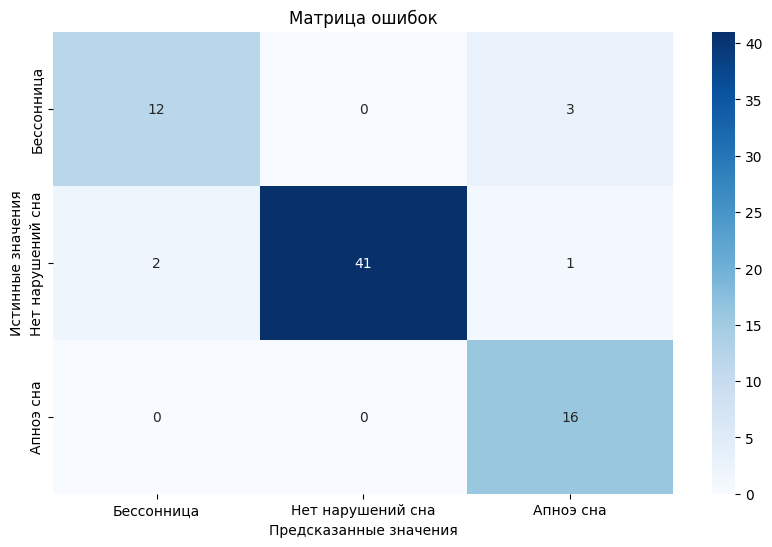


Отчет о классификации:
                   precision    recall  f1-score   support

       Бессонница       0.86      0.80      0.83        15
Нет нарушений сна       1.00      0.93      0.96        44
        Апноэ сна       0.80      1.00      0.89        16

         accuracy                           0.92        75
        macro avg       0.89      0.91      0.89        75
     weighted avg       0.93      0.92      0.92        75



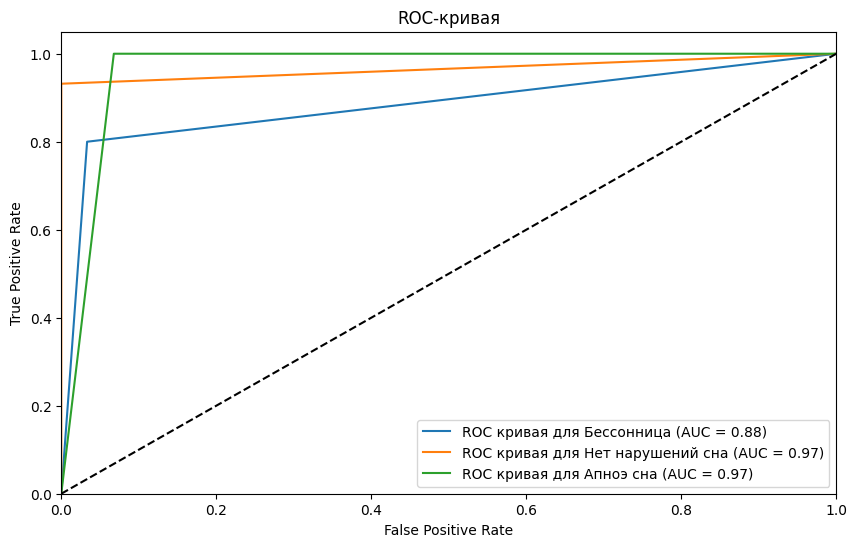

In [26]:
# Построение матрицы ошибок
plt.figure(figsize=(10, 6))
confusion = confusion_matrix(y_test, y_pred_test)
class_names = ['Бессонница', 'Нет нарушений сна', 'Апноэ сна']
sns.heatmap(confusion, annot=True, fmt='d', cmap='Blues', 
            xticklabels=class_names,
            yticklabels=class_names)
plt.title('Матрица ошибок')
plt.xlabel('Предсказанные значения')
plt.ylabel('Истинные значения')
plt.show()

# Отчет о классификации
print("\nОтчет о классификации:")
print(classification_report(y_test, y_pred_test, 
                          target_names=['Бессонница', 'Нет нарушений сна', 'Апноэ сна']))

# ROC-кривая и AUC
plt.figure(figsize=(10, 6))
y_test_bin = label_binarize(y_test, classes=np.unique(y_test))
y_pred_bin = label_binarize(y_pred_test, classes=np.unique(y_pred_test))

n_classes = y_test_bin.shape[1]
class_names = ['Бессонница', 'Нет нарушений сна', 'Апноэ сна']
for i in range(n_classes):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_pred_bin[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f'ROC кривая для {class_names[i]} (AUC = {roc_auc:.2f})')

plt.plot([0, 1], [0, 1], 'k--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC-кривая')
plt.legend(loc="lower right")
plt.show()



# Подбор гиперпараметра K с использованием GridSearchCV

In [27]:
n_neighbors = np.array(range(2,20,2))
param_grid = {'n_neighbors': n_neighbors}
knn = KNeighborsClassifier()
grid_search = GridSearchCV(knn, param_grid, cv=5)
grid_search.fit(X_train, y_train)
print(grid_search.best_params_)
print(grid_search.best_score_)

{'n_neighbors': np.int64(4)}
0.8795480225988701


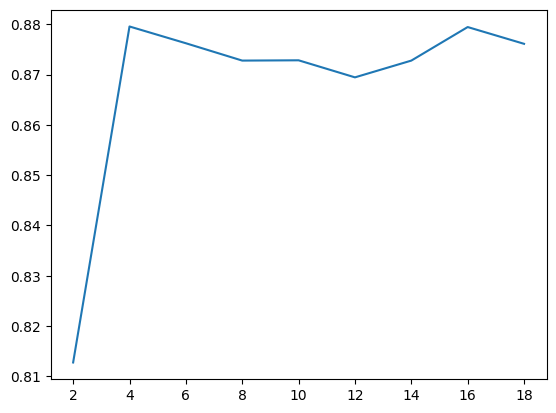

In [28]:
plt.plot(n_neighbors, grid_search.cv_results_['mean_test_score'])

# Подбор гиперпараметра K с использованием RandomizedSearchCV

In [29]:
clf_rs = RandomizedSearchCV(knn, param_grid, cv=2)
clf_rs.fit(X_train, y_train)
print(clf_rs.best_params_)
print(clf_rs.best_score_)

{'n_neighbors': np.int64(4)}
0.8795525727069351


/Users/lans32/Documents/Study/ML_study/ml_env/lib/python3.13/site-packages/sklearn/model_selection/_search.py:317: UserWarning: The total space of parameters 9 is smaller than n_iter=10. Running 9 iterations. For exhaustive searches, use GridSearchCV.
  warnings.warn(


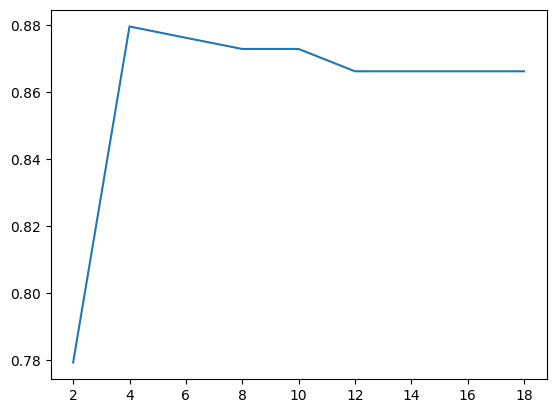

In [30]:
plt.plot(n_neighbors, clf_rs.cv_results_['mean_test_score'])

# Подбор гиперпараметра K с использованием кросс-валидации

In [31]:
scores_LOO = cross_val_score(KNeighborsClassifier(n_neighbors=5), X_train, y_train, cv=LeaveOneOut())
scores_ShuffleSplit = cross_val_score(KNeighborsClassifier(n_neighbors=5), X_train, y_train, cv=ShuffleSplit(n_splits=250, test_size=0.20, random_state=42))
scores_StratifiedKFold = cross_val_score(KNeighborsClassifier(n_neighbors=5), X_train, y_train, cv=StratifiedKFold(n_splits=25))
scores_StratifiedShuffleSplit = cross_val_score(KNeighborsClassifier(n_neighbors=5), X_train, y_train, cv=StratifiedShuffleSplit(n_splits=250, test_size=0.20, random_state=42))


print("Среднее значение точности при кросс-валидации с LeaveOneOut:")
print(scores_LOO.mean())
print("Среднее значение точности при кросс-валидации с ShuffleSplit:")
print(scores_ShuffleSplit.mean())
print("Среднее значение точности при кросс-валидации с StratifiedKFold:")
print(scores_StratifiedKFold.mean())
print("Среднее значение точности при кросс-валидации с StratifiedShuffleSplit:")
print(scores_StratifiedShuffleSplit.mean())


Среднее значение точности при кросс-валидации с LeaveOneOut:
0.882943143812709
Среднее значение точности при кросс-валидации с ShuffleSplit:
0.8754666666666667
Среднее значение точности при кросс-валидации с StratifiedKFold:
0.8866666666666666
Среднее значение точности при кросс-валидации с StratifiedShuffleSplit:
0.8730666666666667


In [32]:
# Подбор гиперпараметров на основе решетчатого поиска и кросс-валидации
n_neighbors = np.array(range(2,20,2))
tuned_parameters = {'n_neighbors': n_neighbors}

In [33]:
%%time
clf_gs_LOO = GridSearchCV(KNeighborsClassifier(), tuned_parameters, cv=LeaveOneOut(), scoring='accuracy')
clf_gs_LOO.fit(X_train, y_train)

CPU times: user 25.8 s, sys: 29.2 s, total: 55.1 s
Wall time: 4.9 s


GridSearchCV(cv=LeaveOneOut(), estimator=KNeighborsClassifier(),
             param_grid={'n_neighbors': array([ 2,  4,  6,  8, 10, 12, 14, 16, 18])},
             scoring='accuracy')

In [34]:
%%time
clf_gs_StratifiedKFold = GridSearchCV(KNeighborsClassifier(), tuned_parameters, cv=StratifiedKFold(n_splits=25), scoring='accuracy')
clf_gs_StratifiedKFold.fit(X_train, y_train)

CPU times: user 2.37 s, sys: 2.77 s, total: 5.14 s
Wall time: 512 ms


GridSearchCV(cv=StratifiedKFold(n_splits=25, random_state=None, shuffle=False),
             estimator=KNeighborsClassifier(),
             param_grid={'n_neighbors': array([ 2,  4,  6,  8, 10, 12, 14, 16, 18])},
             scoring='accuracy')

In [35]:
%%time
clf_gs_StratifiedShuffleSplit = GridSearchCV(KNeighborsClassifier(), tuned_parameters, cv=StratifiedShuffleSplit(n_splits=250, test_size=0.20, random_state=42), scoring='accuracy')
clf_gs_StratifiedShuffleSplit.fit(X_train, y_train)


CPU times: user 30.5 s, sys: 32.5 s, total: 1min 2s
Wall time: 5.57 s


GridSearchCV(cv=StratifiedShuffleSplit(n_splits=250, random_state=42, test_size=0.2,
            train_size=None),
             estimator=KNeighborsClassifier(),
             param_grid={'n_neighbors': array([ 2,  4,  6,  8, 10, 12, 14, 16, 18])},
             scoring='accuracy')

In [36]:
print(clf_gs_LOO.best_params_)
print(clf_gs_StratifiedKFold.best_params_)
print(clf_gs_StratifiedShuffleSplit.best_params_)


{'n_neighbors': np.int64(4)}
{'n_neighbors': np.int64(4)}
{'n_neighbors': np.int64(4)}


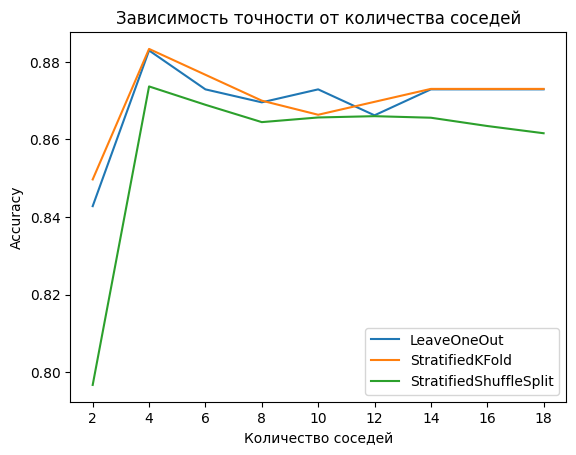

In [37]:
plt.plot(n_neighbors, clf_gs_LOO.cv_results_['mean_test_score'], label='LeaveOneOut')
plt.plot(n_neighbors, clf_gs_StratifiedKFold.cv_results_['mean_test_score'], label='StratifiedKFold')
plt.plot(n_neighbors, clf_gs_StratifiedShuffleSplit.cv_results_['mean_test_score'], label='StratifiedShuffleSplit')
plt.xlabel('Количество соседей')
plt.ylabel('Accuracy')
plt.title('Зависимость точности от количества соседей')
plt.legend()


In [38]:
# Обучение модели и оценка качества с учетом подобранных гиперпараметров
clf_gs_LOO.best_estimator_.fit(X_train, y_train)
clf_gs_StratifiedKFold.best_estimator_.fit(X_train, y_train)
clf_gs_StratifiedShuffleSplit.best_estimator_.fit(X_train, y_train)
targetLOO_0 = clf_gs_LOO.best_estimator_.predict(X_train)
targetLOO_1 = clf_gs_LOO.best_estimator_.predict(X_test)
targetStratifiedKFold_0 = clf_gs_StratifiedKFold.best_estimator_.predict(X_train)
targetStratifiedKFold_1 = clf_gs_StratifiedKFold.best_estimator_.predict(X_test)
targetStratifiedShuffleSplit_0 = clf_gs_StratifiedShuffleSplit.best_estimator_.predict(X_train)
targetStratifiedShuffleSplit_1 = clf_gs_StratifiedShuffleSplit.best_estimator_.predict(X_test)


In [39]:
print('LeaveOneOut:')
print(f'Accuracy на обучающей выборке: {accuracy_score(y_train, targetLOO_0):.3f}')
print(f'Accuracy на тестовой выборке: {accuracy_score(y_test, targetLOO_1):.3f}')

print('\nStratifiedKFold:') 
print(f'Accuracy на обучающей выборке: {accuracy_score(y_train, targetStratifiedKFold_0):.3f}')
print(f'Accuracy на тестовой выборке: {accuracy_score(y_test, targetStratifiedKFold_1):.3f}')

print('\nStratifiedShuffleSplit:')
print(f'Accuracy на обучающей выборке: {accuracy_score(y_train, targetStratifiedShuffleSplit_0):.3f}')
print(f'Accuracy на тестовой выборке: {accuracy_score(y_test, targetStratifiedShuffleSplit_1):.3f}')


LeaveOneOut:
Accuracy на обучающей выборке: 0.906
Accuracy на тестовой выборке: 0.960

StratifiedKFold:
Accuracy на обучающей выборке: 0.906
Accuracy на тестовой выборке: 0.960

StratifiedShuffleSplit:
Accuracy на обучающей выборке: 0.906
Accuracy на тестовой выборке: 0.960


# Сравнение метрики качества исходной и оптимальной моделей.

In [40]:
print('Исходная модель:')
print(f'Accuracy на обучающей выборке: {accuracy_score(y_train, y_pred_train):.3f}')
print(f'Accuracy на тестовой выборке: {accuracy_score(y_test, y_pred_test):.3f}')

print('\nОптимальная модель (StratifiedShuffleSplit):')
print(f'Accuracy на обучающей выборке: {accuracy_score(y_train, targetStratifiedShuffleSplit_0):.3f}')
print(f'Accuracy на тестовой выборке: {accuracy_score(y_test, targetStratifiedShuffleSplit_1):.3f}')

print('\nРазница в точности между моделями:')
print(f'На обучающей выборке: {accuracy_score(y_train, targetStratifiedShuffleSplit_0) - accuracy_score(y_train, y_pred_train):.3f}')
print(f'На тестовой выборке: {accuracy_score(y_test, targetStratifiedShuffleSplit_1) - accuracy_score(y_test, y_pred_test):.3f}')


Исходная модель:
Accuracy на обучающей выборке: 0.893
Accuracy на тестовой выборке: 0.920

Оптимальная модель (StratifiedShuffleSplit):
Accuracy на обучающей выборке: 0.906
Accuracy на тестовой выборке: 0.960

Разница в точности между моделями:
На обучающей выборке: 0.013
На тестовой выборке: 0.040
